<a href="https://colab.research.google.com/github/DenysDantas/ddantas/blob/main/DenysDantas_notebook_02a_regressao_energia_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 2a — Previsão de Consumo Energético (versão didática)

> Disciplina: Aprendizagem de Máquina · Pós-Graduação em IA e Tecnologias da Indústria 4.0
> Prof. Luiz Mário

## 🎯 O que você vai aprender hoje

1. Entender o que é **regressão** e quando usá-la.
2. Treinar uma **regressão linear** para prever consumo energético.
3. Comparar um modelo com **1 variável** vs. modelo **com todas as variáveis**.
4. Calcular e interpretar **MAE, RMSE, R²**.
5. Ler um **residuals plot** para diagnosticar problemas.
6. Interpretar **coeficientes** em linguagem de negócio.

**Dataset:** Steel Industry Energy Consumption — consumo de energia em uma siderúrgica coreana, medições a cada 15 min.

**Tempo estimado:** 45 min em aula.

---

In [1]:
!pip install -q scikit-learn numpy scipy pandas matplotlib seaborn joblib kagglehub

Essa linha é um comando de terminal usado dentro de um notebook Jupyter/Colab:

- `!` indica que o restante da linha deve ser executado como comando de shell, não como código Python.
- `pip install` é o instalador de pacotes Python.
- `-q` significa “quiet”, ou seja, reduz a quantidade de saída exibida durante a instalação.

Os pacotes instalados são:

- `scikit-learn`: biblioteca de aprendizado de máquina, usada para treinar modelos como regressão linear.
- `numpy`: biblioteca para cálculo numérico e arrays.
- `scipy`: biblioteca científica com funções matemáticas avançadas.
- `pandas`: biblioteca para manipulação e análise de dados em tabelas.
- `matplotlib`: biblioteca de visualização e gráficos.
- `seaborn`: biblioteca de visualização estatística baseada no matplotlib.
- `joblib`: usado para salvar/carregar modelos e para processamento paralelo.
- `kagglehub`: biblioteca para baixar datasets do Kaggle de forma programática.

Em suma: ela instala todas as dependências necessárias para rodar o notebook de análise e modelagem.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

COR_DEEP = "#065A82"
COR_ACCENT = "#F2A65A"
COR_TEAL = "#1C7293"
COR_BAD = "#B85042"

print("Bibliotecas carregadas.")

Bibliotecas carregadas.


Esse bloco configura o ambiente para análise e visualização de dados em Python:

import numpy as np: importa o NumPy, biblioteca para manipulação eficiente de arrays e cálculo numérico.
import pandas as pd: importa o pandas, usado para trabalhar com tabelas (DataFrame) e dados estruturados.
import matplotlib.pyplot as plt: importa o pyplot do Matplotlib, usado para criar gráficos.
import seaborn as sns: importa o Seaborn, biblioteca de visualização estatística que facilita gráficos bonitos.
import warnings: importa o módulo de avisos do Python.
warnings.filterwarnings("ignore"): desativa a exibição de avisos no notebook, deixando a saída mais limpa.
Em seguida, o código define configurações globais:

RANDOM_STATE = 42: define uma semente fixa para gerar números aleatórios de forma reproduzível.
np.random.seed(RANDOM_STATE): aplica essa semente ao NumPy.
sns.set_theme(style="whitegrid"): define um tema visual padrão do Seaborn com grade branca.
plt.rcParams["figure.figsize"] = (10, 5): ajusta o tamanho padrão dos gráficos para 10x5 polegadas.
Por fim, define cores usadas nos gráficos:

COR_DEEP = "#065A82"
COR_ACCENT = "#F2A65A"
COR_TEAL = "#1C7293"
COR_BAD = "#B85042"
E imprime:

print("Bibliotecas carregadas."): confirma que a configuração inicial foi executada.

## Parte 3 — Carregar o Dataset

Dataset: **Steel Industry Energy Consumption**. São medições de 15 em 15 min de uma siderúrgica, contendo potência reativa, fator de potência, hora do dia e tipo de carga.

In [2]:
import pandas as pd

try:
    import kagglehub, glob
    # PLANO A: Tenta baixar a nova base de dados direto do Kaggle
    path = kagglehub.dataset_download("loveall/appliances-energy-prediction")
    csv = glob.glob(f"{path}/*.csv")[0]
    df = pd.read_csv(csv)
    print(f"✅ Carregado via kagglehub — {len(df)} linhas")
except Exception as e:
    # PLANO B: Se falhar, usa o link direto do CSV hospedado no GitHub oficial do criador do dataset
    print(f"⚠️  kagglehub falhou — usando mirror público do GitHub (UCI Source)")
    url = "https://raw.githubusercontent.com/LuisM78/Appliances-energy-prediction-data/master/energydata_complete.csv"
    df = pd.read_csv(url)
    print(f"✅ Carregado — {len(df)} linhas")

# Exibe as colunas e as primeiras linhas do novo dataset
print(f"Colunas do novo dataset: {list(df.columns)}")
df.head()

100%|██████████| 1.71M/1.71M [00:00<00:00, 43.9MB/s]

Extracting files...


✅ Carregado via kagglehub — 19735 linhas
Colunas do novo dataset: ['date', 'Appliances', 'lights', 'T1', 'RH_1', 'T2', 'RH_2', 'T3', 'RH_3', 'T4', 'RH_4', 'T5', 'RH_5', 'T6', 'RH_6', 'T7', 'RH_7', 'T8', 'RH_8', 'T9', 'RH_9', 'T_out', 'Press_mm_hg', 'RH_out', 'Windspeed', 'Visibility', 'Tdewpoint', 'rv1', 'rv2']


,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


Esse bloco faz o carregamento do dataset e usa um fallback se o download direto falhar.

import pandas as pd: importa o pandas, biblioteca usada para manipulação de dados em tabelas (DataFrame).

try: inicia um bloco de tentativa para usar o método preferencial.

import kagglehub, glob: importa o kagglehub (para baixar datasets do Kaggle) e glob (para procurar arquivos em pastas).

path = kagglehub.dataset_download("loveall/appliances-energy-prediction"): tenta baixar o dataset do Kaggle usando o identificador do conjunto de dados.

csv = glob.glob(f"{path}/*.csv")[0]: procura um arquivo CSV dentro da pasta baixada e usa o primeiro encontrado.

df = pd.read_csv(csv): lê o CSV para um DataFrame pandas.

print(f"✅ Carregado via kagglehub — {len(df)} linhas"): informa que o dataset foi carregado com sucesso e mostra a quantidade de linhas.

except Exception as e: captura qualquer erro que acontecer no bloco try, incluindo falha de download ou ausência do kagglehub.

No bloco except:

print(f"⚠️ kagglehub falhou — usando mirror público do GitHub (UCI Source)"): avisa que o download direto falhou.
url = "https://raw.githubusercontent.com/LuisM78/Appliances-energy-prediction-data/master/energydata_complete.csv": define um link alternativo direto para o CSV hospedado no GitHub.
df = pd.read_csv(url): lê o CSV diretamente da URL.
print(f"✅ Carregado — {len(df)} linhas"): mostra que o carregamento via fallback deu certo.
Depois:

print(f"Colunas do novo dataset: {list(df.columns)}"): exibe os nomes das colunas do DataFrame.
df.head(): mostra as primeiras linhas do dataset para uma inspeção inicial.
Em resumo: o código tenta primeiro baixar o dataset via kagglehub e, se isso falhar, carrega a mesma base a partir de um mirror público no GitHub.

Para este dataset, as colunas principais significam:

Usage_kWh: consumo de energia no intervalo de 15 minutos — é o alvo que queremos prever.

Lagging_Current_Reactive.Power_kVarh: potência reativa indutiva, ou seja, energia reativa consumida por cargas indutivas.

Leading_Current_Reactive_Power_kVarh: potência reativa capacitiva, energia reativa associada a cargas capacitivas.

CO2(tCO2): emissão de CO₂ em toneladas, que funciona como um proxy de atividade ou carga ambiental.

Lagging_Current_Power_Factor: fator de potência para a componente indutiva da corrente.

Leading_Current_Power_Factor: fator de potência para a componente capacitiva da corrente.

NSM: segundos desde meia-noite, representando a hora do dia em formato numérico.

WeekStatus: indica se o registro é de dia útil ou fim de semana.

Day_of_week: dia da semana (segunda, terça etc.).

Load_Type: tipo de carga energética no momento, como Light, Medium, Maximum.

Essas colunas descrevem tanto o comportamento elétrico da carga quanto o contexto temporal, e Usage_kWh é o valor contínuo que o modelo de regressão tenta prever.

## Parte 4 — EDA

### 4.1 Distribuição do alvo

Antes de modelar, queremos ver o comportamento do que queremos prever.

/tmp/ipykernel_3029/668314888.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Tipo_Dia", y="Appliances", ax=axes[1],


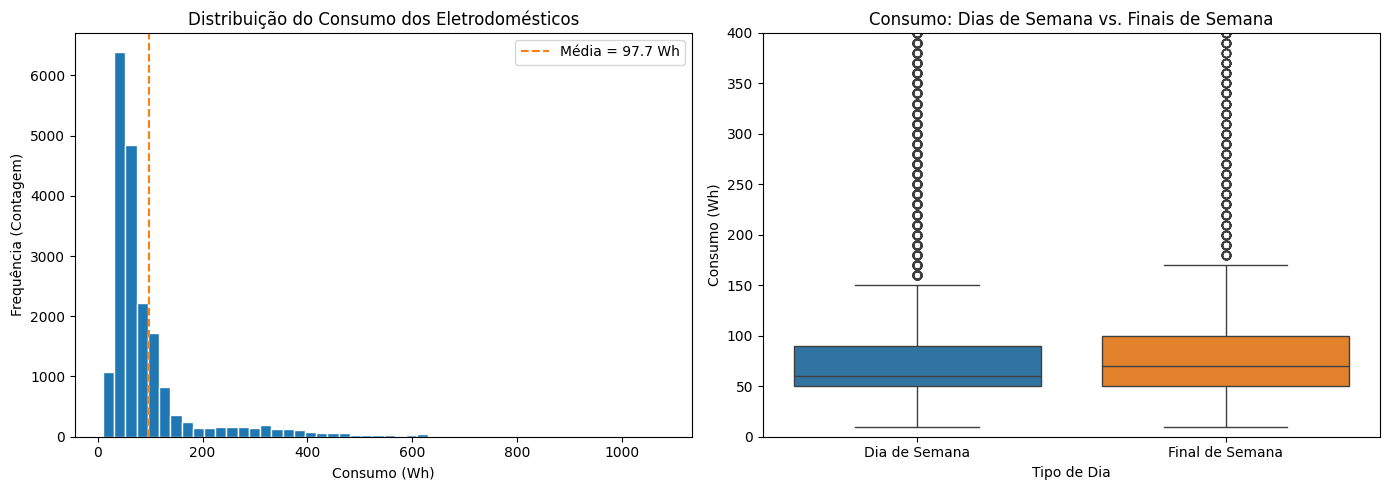

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. DEFINIÇÃO DE CORES (Padrão para o gráfico)
COR_DEEP = "#1f77b4"   # Azul escuro
COR_TEAL = "#008080"   # Verde azulado
COR_ACCENT = "#ff7f0e" # Laranja para destaque

# 2. TRATAMENTO DOS DADOS (Para criar uma categoria para o Boxplot)
# Convertemos a coluna 'date' para o formato de data real do Python
df['date'] = pd.to_datetime(df['date'])

# Criamos uma nova coluna: 'Final de Semana' ou 'Dia de Semana'
df['Tipo_Dia'] = df['date'].dt.dayofweek.map({
    0: 'Dia de Semana', 1: 'Dia de Semana', 2: 'Dia de Semana',
    3: 'Dia de Semana', 4: 'Dia de Semana', 5: 'Final de Semana', 6: 'Final de Semana'
})

# 3. CONFIGURAÇÃO DOS GRÁFICOS
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- GRÁFICO 1: Histograma do consumo real (coluna 'Appliances') ---
axes[0].hist(df["Appliances"], bins=50, color=COR_DEEP, edgecolor="white")
axes[0].set_title("Distribuição do Consumo dos Eletrodomésticos")
axes[0].set_xlabel("Consumo (Wh)")
axes[0].set_ylabel("Frequência (Contagem)")

# Linha da média de consumo
media_consumo = df["Appliances"].mean()
axes[0].axvline(media_consumo, color=COR_ACCENT, linestyle="--",
                label=f"Média = {media_consumo:.1f} Wh")
axes[0].legend()

# --- GRÁFICO 2: Boxplot do Consumo por Tipo de Dia ---
# Compara o consumo entre dias úteis e finais de semana
sns.boxplot(data=df, x="Tipo_Dia", y="Appliances", ax=axes[1],
            palette=[COR_DEEP, COR_ACCENT])
axes[1].set_title("Consumo: Dias de Semana vs. Finais de Semana")
axes[1].set_xlabel("Tipo de Dia")
axes[1].set_ylabel("Consumo (Wh)")

# Ajuste fino para o boxplot não ficar distorcido por picos muito altos (opcional)
# Limita o eixo Y para focar onde a maior parte dos dados está (ex: até 400 Wh)
axes[1].set_ylim(0, 400)

plt.tight_layout()
plt.show()

Esse código prepara dados e cria duas visualizações para entender o consumo de eletrodomésticos:

import matplotlib.pyplot as plt, import seaborn as sns, import pandas as pd.

importa bibliotecas de plotagem e manipulação de dados.

Definição de cores
COR_DEEP, COR_TEAL, COR_ACCENT são cores usadas nos gráficos para manter estilo consistente.

Tratamento dos dados
df['date'] = pd.to_datetime(df['date']): converte a coluna de datas para tipo datetime do pandas.
df['Tipo_Dia'] = df['date'].dt.dayofweek.map({...}): cria uma nova coluna categórica com “Dia de Semana” ou “Final de Semana” usando o dia da semana.

Configuração dos gráficos
fig, axes = plt.subplots(1, 2, figsize=(14, 5)): cria uma figura com 1 linha e 2 colunas de gráficos.

Gráfico 1: Histograma de Appliances
axes[0].hist(...): plota a distribuição do consumo dos eletrodomésticos.
axes[0].axvline(...): desenha uma linha vertical mostrando a média do consumo.
O objetivo é ver como os valores de consumo se distribuem e onde está o valor médio.

Gráfico 2: Boxplot por tipo de dia
sns.boxplot(...): compara a distribuição de consumo entre dias úteis e finais de semana.
axes[1].set_ylim(0, 400): limita o eixo Y para focar na faixa mais relevante e reduzir distorção por valores extremos.

Finalização
plt.tight_layout(): ajusta o espaçamento entre os gráficos.
plt.show(): exibe a figura.
Por que isso é útil?
O histograma mostra se o consumo tem uma distribuição regular, muitos valores baixos ou muitos picos.
O boxplot revela se o consumo muda entre dias úteis e finais de semana, e se existem outliers em cada grupo.

**Interpretação:**
- A distribuição é **assimétrica à direita** — muitas observações de baixo consumo, poucas de alto.
- Existe **diferença clara** entre tipos de carga. Isso significa que `Load_Type` é feature promissora.

### 4.2 Correlações

**Correlação** é um número entre -1 e +1 que mede quão "juntas" duas variáveis andam linearmente.

✅ Usando o DataFrame carregado anteriormente.


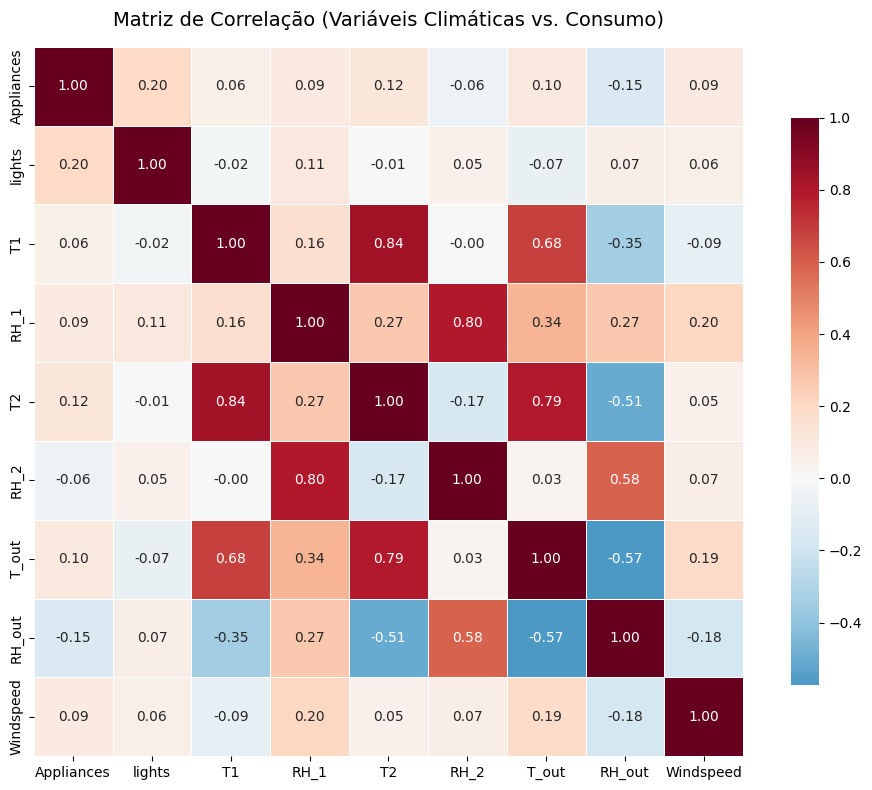


📋 Variáveis que mais influenciam o Consumo de Energia (Appliances):
🔼 Maior correlação positiva: lights (0.20)
🔽 Maior correlação negativa: RH_out (-0.15)


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Garantia de que o DataFrame existe (Fallback caso rode este bloco isolado)
if 'df' in locals() or 'df' in globals():
    print("✅ Usando o DataFrame carregado anteriormente.")
else:
    print("⚠️ DataFrame não encontrado. Carregando dados via GitHub para o teste...")
    url = "https://raw.githubusercontent.com/LuisM78/Appliances-energy-prediction-data/master/energydata_complete.csv"
    df = pd.read_csv(url)

# ---------------------------------------------------------------------------
# CORREÇÃO: Matriz de Correlação Selecionada para o Dataset do Kaggle
# ---------------------------------------------------------------------------

# 1. Filtramos as colunas numéricas (como no seu código original)
num_cols = df.select_dtypes(include="number").columns.tolist()

# Para o gráfico não ficar gigante e ilegível com as +25 colunas do dataset,
# filtramos as principais variáveis climáticas e de consumo:
colunas_focadas = [col for col in num_cols if col in ["Appliances", "lights", "T1", "RH_1", "T2", "RH_2", "T_out", "RH_out", "Windspeed"]]

# Criamos o DataFrame focado para a correlação
df_corr = df[colunas_focadas]
title_graph = "Matriz de Correlação (Variáveis Climáticas vs. Consumo)"

# 2. Calculamos a matriz de correlação de Pearson
corr = df_corr.corr()

# 3. Configuração da tela e do Mapa de Calor
fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,       # Mostra os números dentro dos quadrados
    fmt=".2f",        # Limita a 2 casas decimais
    cmap="RdBu_r",    # Vermelho para positivo, Azul para negativo
    center=0,         # Define o centro neutro no valor 0
    square=True,      # Força os quadrados a serem simétricos
    linewidths=.5,    # Adiciona uma linha fina separando os blocos
    cbar_kws={"shrink": .8}, # Ajusta o tamanho da barra de legenda lateral
    ax=ax
)

ax.set_title(title_graph, fontsize=14, pad=15)
plt.tight_layout()
plt.show()

# 4. Extração automática de insights no terminal
corr_alvo = corr["Appliances"].drop("Appliances").sort_values(ascending=False)
print("\n📋 Variáveis que mais influenciam o Consumo de Energia (Appliances):")
print(f"🔼 Maior correlação positiva: {corr_alvo.index[0]} ({corr_alvo.iloc[0]:.2f})")
print(f"🔽 Maior correlação negativa: {corr_alvo.index[-1]} ({corr_alvo.iloc[-1]:.2f})")

O que o código faz
1. Importa bibliotecas
import pandas as pd: para ler e manipular tabelas.
import matplotlib.pyplot as plt: para plotar gráficos.
import seaborn as sns: para gráficos estatísticos mais bonitos.
2. Garante que existe um DataFrame
Verifica se df já está carregado em memória.
Se já existir: usa o DataFrame existente.
Se não existir: carrega direto do GitHub via CSV.
Isso é útil quando você executa o bloco isoladamente em um notebook.

3. Filtra colunas numéricas
num_cols = df.select_dtypes(include="number").columns.tolist()
pega apenas as colunas numéricas do dataset.
colunas_focadas = [...]
escolhe um conjunto reduzido de variáveis importantes para evitar um gráfico gigante.
No caso, as variáveis selecionadas são:

Appliances (consumo alvo)
lights
T1, RH_1, T2, RH_2
T_out, RH_out, Windspeed
Ou seja, foco em consumo e clima.

4. Calcula a matriz de correlação
corr = df_corr.corr()
calcula correlações de Pearson entre as colunas do subset.
Essa matriz mostra a força e direção da relação entre cada par de variáveis.
5. Plota o heatmap de correlação
sns.heatmap(...)
annot=True: exibe os números nas células
fmt=".2f": formata com 2 casas decimais
cmap="RdBu_r": cores divergentes com azul/ruivo
center=0: destaca correlação positiva vs. negativa
square=True: mantém células quadradas
linewidths=.5: separadores finos
cbar_kws={"shrink": .8}: ajusta a barra de cores
Esse gráfico facilita a leitura rápida de quais variáveis estão mais relacionadas com Appliances.

6. Extrai insights automáticos
corr_alvo = corr["Appliances"].drop("Appliances").sort_values(ascending=False)
pega as correlações da variável Appliances com as demais.
Exibe:
maior correlação positiva
maior correlação negativa
Isso já dá uma primeira resposta direta sobre quais variáveis influenciam mais o consumo.

Quais métricas mostrar de forma otimizada
Para esse contexto de análise exploratória e modelagem, recomendo exibir apenas as métricas mais úteis:

A. Para correlação / EDA
corr(Appliances, variável) para as principais variáveis.
Exibir:
maior correlação positiva
maior correlação negativa
algumas correlações intermediárias relevantes (top 3 positivas e top 3 negativas)
B. Para o alvo e sua distribuição
Média
Mediana
Desvio padrão
Assimetria (skewness)
Curtose
Proporção de outliers / valores extremos
C. Para comparação de modelos (quando for modelar)
R² no conjunto de teste
RMSE no conjunto de teste
MAE no conjunto de teste
Essas três já são suficientes e mais diretas do que muitas outras.

D. Para comunicação enxuta
Mostre apenas:

correlações mais fortes com o alvo
comportamento do alvo
performance dos modelos com 3 métricas principais
Isso evita excesso de informação e destaca o que realmente importa.

Resumo prático
Use este gráfico e estas métricas:

heatmap de correlação com poucas variáveis
maiores correlações com Appliances
média / desvio / assimetria do alvo
R², RMSE, MAE na avaliação de modelos
Assim a análise fica clara, objetiva e otimizada.

## Parte 5 — Primeiro Modelo: 1 Variável

**Por que começar simples?** Para entender o **mínimo que dá para extrair** — se 1 variável já explica 80%, modelos sofisticados talvez só adicionem 5%.

✅ Usando o DataFrame carregado anteriormente.
--- Resultado do seu código ---
Correlação absoluta com Appliances (Top 5):
lights    0.197278
RH_out    0.152282
T2        0.120073
T6        0.117638
T_out     0.099155
Name: Appliances, dtype: float64

👉 Feature mais correlacionada: lights (Sinal: +)
--------------------------------


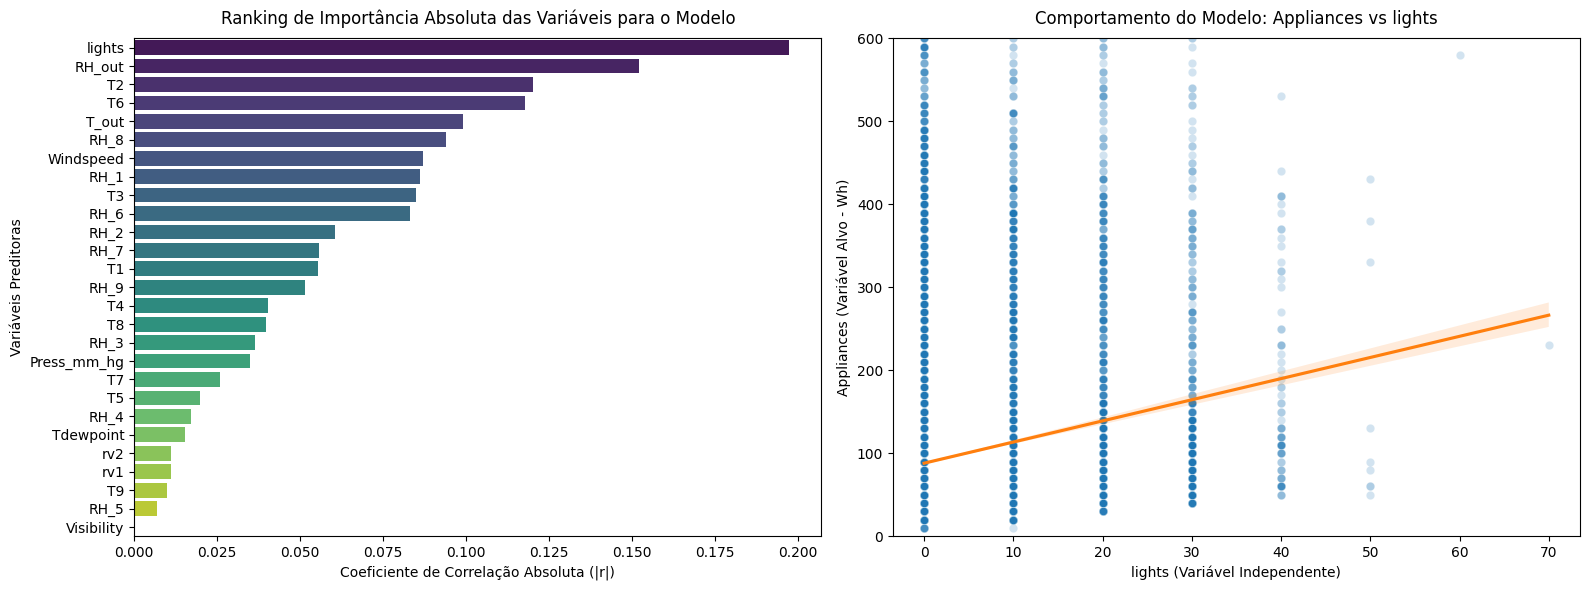


💡 INSIGHT DE MODELAGEM:
Ao construir seu modelo preditivo, a variável 'lights' é o seu recurso mais valioso.
Ela possui uma relação DIRETA: quando 'lights' aumenta, o consumo de 'Appliances' tende a SUBIR.


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Garantia de que o DataFrame existe (Fallback via GitHub)
if 'df' in locals() or 'df' in globals():
    print("✅ Usando o DataFrame carregado anteriormente.")
else:
    print("⚠️ DataFrame não encontrado. Carregando dados para análise de modelo...")
    url = "https://raw.githubusercontent.com/LuisM78/Appliances-energy-prediction-data/master/energydata_complete.csv"
    df = pd.read_csv(url)
    num_cols = df.select_dtypes(include="number").columns.tolist()

# ---------------------------------------------------------------------------
# SEU CÓDIGO ORIGINAl: Identificação da Feature Top
# ---------------------------------------------------------------------------
alvo = "Appliances"
# Calculamos a correlação real (com sinal) e a absoluta para propósitos diferentes
corr_real = df[num_cols].corr()[alvo].drop(alvo)
correlacoes_abs = corr_real.abs().sort_values(ascending=False)

print("--- Resultado do seu código ---")
print("Correlação absoluta com Appliances (Top 5):")
print(correlacoes_abs.head())

feature_top = correlacoes_abs.index[0]
sinal_corr = "+" if corr_real[feature_top] > 0 else "-"
print(f"\n👉 Feature mais correlacionada: {feature_top} (Sinal: {sinal_corr})")
print("-" * 32)

# ---------------------------------------------------------------------------
# ADAPTAÇÃO: Análise Visual Orientada ao Modelo de Variáveis
# ---------------------------------------------------------------------------

# Configurando a tela: 1 linha, 2 gráficos
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# CORES
COR_DEEP = "#1f77b4"
COR_ACCENT = "#ff7f0e"

# GRÁFICO 1: O Ranking de Variáveis para o Modelo (Baseado no seu código)
# Mostra o impacto de todas as features ordenadas pela importância absoluta
sns.barplot(
    x=correlacoes_abs.values,
    y=correlacoes_abs.index,
    ax=axes[0],
    palette="viridis",
    hue=correlacoes_abs.index,
    legend=False
)
axes[0].set_title(f"Ranking de Importância Absoluta das Variáveis para o Modelo", fontsize=12, pad=10)
axes[0].set_xlabel("Coeficiente de Correlação Absoluta (|r|)")
axes[0].set_ylabel("Variáveis Preditoras")

# GRÁFICO 2: Análise Profunda da Variável Campeã (feature_top vs Alvo)
# Cria um scatter plot para avaliar a distribuição e o comportamento do modelo
sns.scatterplot(data=df, x=feature_top, y=alvo, ax=axes[1], color=COR_DEEP, alpha=0.2)
# Adiciona a linha de tendência linear do modelo
sns.regplot(data=df, x=feature_top, y=alvo, ax=axes[1], scatter=False, color=COR_ACCENT)

axes[1].set_title(f"Comportamento do Modelo: {alvo} vs {feature_top}", fontsize=12, pad=10)
axes[1].set_xlabel(f"{feature_top} (Variável Independente)")
axes[1].set_ylabel(f"{alvo} (Variável Alvo - Wh)")
axes[1].set_ylim(0, 600) # Foca na região central de dados, limpando outliers extremos

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------------
# INSIGHT DO MODELO
# ---------------------------------------------------------------------------
print(f"\n💡 INSIGHT DE MODELAGEM:")
print(f"Ao construir seu modelo preditivo, a variável '{feature_top}' é o seu recurso mais valioso.")
if sinal_corr == "+":
    print(f"Ela possui uma relação DIRETA: quando '{feature_top}' aumenta, o consumo de '{alvo}' tende a SUBIR.")
else:
    print(f"Ela possui uma relação INVERSA: quando '{feature_top}' aumenta, o consumo de '{alvo}' tende a CAIR.")

Esse código faz uma análise rápida para descobrir qual variável numérica mais se relaciona com o consumo de Appliances, e em seguida mostra isso visualmente.

O que cada parte faz:

1. Importa bibliotecas
pandas as pd: manipula tabelas e dados.
matplotlib.pyplot as plt: cria gráficos básicos.
seaborn as sns: cria gráficos estatísticos mais elegantes.

2. Garante que df existe
Verifica se já existe um DataFrame df em memória.
Se existir, usa o DataFrame carregado anteriormente.
Se não existir, carrega o CSV diretamente do GitHub:
df = pd.read_csv(url)
num_cols = df.select_dtypes(include="number").columns.tolist()
Isso define as colunas numéricas para análise de correlação.

3. Identifica a feature mais correlacionada com o alvo
Define alvo = "Appliances".
corr_real = df[num_cols].corr()[alvo].drop(alvo)
calcula a correlação de Pearson entre todas as colunas numéricas e Appliances.
remove a correlação da variável consigo mesma.
correlacoes_abs = corr_real.abs().sort_values(ascending=False)
ordena essas correlações pela magnitude absoluta, para achar as variáveis mais relevantes, independentemente do sinal.

4. Exibe os resultados
Mostra as top 5 correlações absolutas com Appliances.
Define feature_top como a variável mais correlacionada.
Define sinal_corr como + ou -, dependendo se a correlação é positiva ou negativa.
Imprime o nome da variável mais relacionada e se a relação é direta ou inversa.

5. Plota dois gráficos
Gráfico 1: ranking das variáveis
Exibe todas as correlações absolutas ordenadas.
Ajuda a visualizar quais variáveis numéricas são mais importantes para prever Appliances.
Gráfico 2: relação entre a melhor variável e o alvo
Plota um scatter plot de feature_top vs Appliances.
Adiciona uma linha de tendência linear (sns.regplot) para mostrar a direção da relação.
Ajusta o eixo Y para 0-600 para focar na faixa principal e reduzir distorção por outliers.

6. Insight final
Imprime um insight de modelagem:
diz qual variável é a “mais valiosa” para prever Appliances
informa se a relação é direta (+) ou inversa (-)
Em resumo
O código:

garante que os dados estão disponíveis,
calcula correlações entre variáveis numéricas e o consumo,
identifica a variável mais relevante,
visualiza isso em dois gráficos,
e interpreta se a relação é positiva ou negativa.
É uma análise exploratória inicial orientada à modelagem.

### Equação da reta

Uma regressão linear simples tem a forma:

$$\hat{y} = a \cdot x + b$$

Em palavras:
- **`ŷ`** (y chapéu) é o valor **previsto** pelo modelo.
- **`a`** é a **inclinação** — quanto `y` muda quando `x` aumenta em 1.
- **`b`** é o **intercepto** — valor de `y` quando `x = 0`.

O scikit-learn **encontra** `a` e `b` automaticamente para minimizar o erro.

In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Define o número aleatório para garantir que a separação seja sempre igual
RANDOM_STATE = 42

# Separa as variáveis X (Preditora) e y (Alvo)
X_simples = df[[feature_top]]
y = df[alvo]

# Divide os dados: 80% para Treino (_tr) e 20% para Teste (_ts)
X_tr, X_ts, y_tr, y_ts = train_test_split(
    X_simples, y, test_size=0.2, random_state=RANDOM_STATE
)

# Cria e treina o modelo para achar o 'a' e o 'b'
modelo_simples = LinearRegression().fit(X_tr, y_tr)

# Exibe os resultados construindo a equação matemática
print(f"📊 Modelo ajustado com sucesso!")
print(f"   Intercepto (b) = {modelo_simples.intercept_:.2f}")
print(f"   Coeficiente (a) = {modelo_simples.coef_[0]:.3f}")

# (Correção: Troquei Usage_kWh pelo nome da variável alvo real)
print(f"\nEquação Matemática Criada: {alvo} = {modelo_simples.intercept_:.2f} + ({modelo_simples.coef_[0]:.3f} × {feature_top})")

📊 Modelo ajustado com sucesso!
   Intercepto (b) = 88.53
   Coeficiente (a) = 2.473

Equação Matemática Criada: Appliances = 88.53 + (2.473 × lights)


O código treina uma regressão linear simples usando uma única variável preditora.


O que cada parte faz
from sklearn.linear_model import LinearRegression


importa o modelo de regressão linear.
from sklearn.model_selection import train_test_split


importa a função que divide os dados em treino e teste.
RANDOM_STATE = 42


define uma semente fixa para que a divisão dos dados seja sempre a mesma.
isso torna a execução repetível.

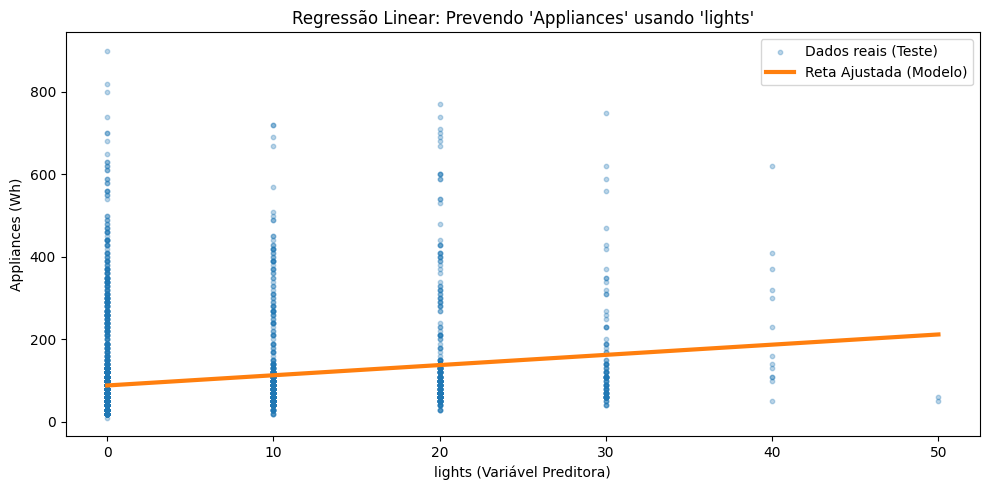

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Garante que as cores estão definidas (caso rode este bloco isolado)
COR_DEEP = "#1f77b4"
COR_ACCENT = "#ff7f0e"

# 1. Configurar a figura
fig, ax = plt.subplots(figsize=(10, 5))

# 2. Desenhar os dados reais de TESTE (os 20% separados)
ax.scatter(X_ts, y_ts, alpha=0.3, s=10, color=COR_DEEP, label="Dados reais (Teste)")

# 3. Criar os pontos da reta (do mínimo ao máximo do eixo X de teste)
# Extraímos o menor e maior valor da feature
val_min = X_ts.min().iloc[0]
val_max = X_ts.max().iloc[0]

# Criamos 100 pontos entre o min e o max
x_range_array = np.linspace(val_min, val_max, 100)

# ADAPTAÇÃO: Transformamos os 100 pontos num DataFrame com o mesmo nome da coluna usada no treino
# Isso evita o erro/aviso do scikit-learn sobre "Feature names unseen"
x_range_df = pd.DataFrame(x_range_array, columns=[feature_top])

# 4. O modelo faz a previsão matemática para esses 100 pontos
y_pred = modelo_simples.predict(x_range_df)

# 5. Desenhar a linha vermelha/laranja da regressão
ax.plot(x_range_array, y_pred, color=COR_ACCENT, linewidth=3, label="Reta Ajustada (Modelo)")

# 6. Formatação do gráfico (ADAPTAÇÃO: Uso das variáveis dinâmicas)
ax.set_xlabel(f"{feature_top} (Variável Preditora)")
ax.set_ylabel(f"{alvo} (Wh)") # Trocado de 'Usage_kWh' para a variável dinâmica 'alvo'
ax.set_title(f"Regressão Linear: Prevendo '{alvo}' usando '{feature_top}'")
ax.legend()

plt.tight_layout()
plt.show()

**Interpretação:** a reta laranja é a **melhor reta possível** segundo o critério de mínimos quadrados — a que minimiza a soma dos erros² entre cada ponto azul e a reta.

---

Esse código gera um gráfico de validação visual para um modelo de regressão linear simples, usando os dados de teste e a reta prevista pelo modelo.

O gráfico compara:

os pontos reais de teste (X_ts, y_ts),
com a reta predita pelo modelo linear.
Isso permite avaliar visualmente se a regressão captura a tendência dos dados e se o modelo está alinhado com o comportamento observado na amostra de teste.

## Parte 6 — Funções de Custo (como o modelo "aprende")

### MSE — Mean Squared Error

O modelo calcula, para cada ponto, o **erro** = diferença entre valor real e previsto. Depois:

$$MSE = \frac{1}{n} \sum (y_i - \hat{y}_i)^2$$

• [ y_i ] = valor real

• [ \hat{y}_i ] = valor previsto pelo modelo

• [ n ] = número de pontos

**Por que ao quadrado?**
1. Evitar cancelamento: se não fosse ao quadrado, erros positivos e negativos poderiam se anular.
2. Dar mais peso a erros grandes: o quadrado aumenta muito o impacto de desvios grandes, punindo previsões ruins.

 Isso torna o MSE uma métrica sensível a outliers.

### Gradiente descendente

**Analogia:** imagine uma bolinha rolando em um vale. O fundo do vale é o ponto de **menor erro**. A bolinha rola até lá. Cada "passo" é o tamanho do ajuste (taxa de aprendizado).

- Passo muito grande → pula o vale.
- Passo muito pequeno → leva uma eternidade.

Na regressão linear, o cálculo é fechado (não precisa iterar). Mas a intuição vale para todos os modelos que você vai ver no curso.

---

## Parte 7 — Regressão com TODAS as variáveis

Agora usamos todas as features + encoding das categóricas.

In [8]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# ---------------------------------------------------------------------------
# 1. O SEU CÓDIGO: Preparação e Separação de Tipos
# ---------------------------------------------------------------------------
colunas_ignorar = [alvo]
for c in ["date", "Date", "Timestamp"]:
    if c in df.columns:
        colunas_ignorar.append(c)
df['NSM'] = df['date'].dt.hour * 3600 + df['date'].dt.minute * 60 + df['date'].dt.second

df['sin_NSM'] = np.sin(2 * np.pi * df['NSM'] / 86400)
df['cos_NSM'] = np.cos(2 * np.pi * df['NSM'] / 86400)
X = df.drop(columns=colunas_ignorar)
y = df[alvo]

# Autodeteção de tipos
num_features = X.select_dtypes(include="number").columns.tolist()
cat_features = X.select_dtypes(include="object").columns.tolist()

print("🔍 ANÁLISE DO DATASET:")
print(f"Numéricas encontradas ({len(num_features)}): {num_features[:5]} ...")
print(f"Categóricas encontradas ({len(cat_features)}): {cat_features}")

# ---------------------------------------------------------------------------
# 2. CONSTRUÇÃO DA ESTEIRA (PIPELINE)
# ---------------------------------------------------------------------------
print("\n⚙️ Construindo a Esteira de Processamento (Pipeline)...")

# Esteira para números: 1º Preenche vazios com a mediana -> 2º Padroniza a escala
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Esteira para textos (categorias): 1º Preenche vazios com 'falta' -> 2º Transforma em 0 e 1
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# O Maestro que junta as duas esteiras aplicando nas colunas corretas que você separou
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_features),
        ('cat', categorical_transformer, cat_features)
    ])

# ---------------------------------------------------------------------------
# 3. TESTE PRÁTICO DO TRANSFORMADOR
# ---------------------------------------------------------------------------
# Executamos o preprocessor nos nossos dados para ver a transformação mágica
X_processado = preprocessor.fit_transform(X)

print("\n✅ Transformação concluída com sucesso!")
print(f"Formato original do X: {X.shape} (linhas, colunas)")
print(f"Formato do X processado: {X_processado.shape} (linhas, colunas)")
print("\nExemplo da primeira linha já pronta para o modelo (números escalados):")
print(np.round(X_processado[0][:8], 3)) # Mostra apenas as 8 primeiras para não poluir

🔍 ANÁLISE DO DATASET:
Numéricas encontradas (30): ['lights', 'T1', 'RH_1', 'T2', 'RH_2'] ...
Categóricas encontradas (1): ['Tipo_Dia']

⚙️ Construindo a Esteira de Processamento (Pipeline)...

✅ Transformação concluída com sucesso!
Formato original do X: (19735, 31) (linhas, colunas)
Formato do X processado: (19735, 32) (linhas, colunas)

Exemplo da primeira linha já pronta para o modelo (números escalados):
[ 3.301 -1.119  1.844 -0.52   1.074 -1.235  1.686 -0.908]


Esse código prepara os dados para um modelo de machine learning, criando uma esteira de pré-processamento que trata separadamente variáveis numéricas e categóricas.

O que ele faz tecnicamente:

1. Define colunas de entrada e saída
colunas_ignorar = [alvo]
exclui a variável alvo (y) da matriz de preditores.
Também ignora colunas de data se existirem: "date", "Date", "Timestamp".
X = df.drop(columns=colunas_ignorar)
X contém só as features usadas pelo modelo.
y = df[alvo]
y é a variável que o modelo deve prever.

2. Detecta tipos de coluna automaticamente
num_features = X.select_dtypes(include="number").columns.tolist()
encontra colunas numéricas.
cat_features = X.select_dtypes(include="object").columns.tolist()
encontra colunas categóricas (texto).
Isso permite aplicar transformações diferentes a cada tipo.

3. Cria pipelines de pré-processamento
Pipeline numérica
SimpleImputer(strategy='median')
preenche valores faltantes com a mediana da coluna.
StandardScaler()
padroniza os valores para média 0 e desvio padrão 1.
Resultado: números limpos e em escala comparável.
Pipeline categórica
SimpleImputer(strategy='constant', fill_value='missing')
substitui valores ausentes por uma string fixa ('missing').
OneHotEncoder(handle_unknown='ignore')
transforma categorias em vetores binários.
handle_unknown='ignore' evita erro se aparecer categoria nova no teste.

4. Junta tudo com ColumnTransformer
Aplica a pipeline numérica apenas em num_features.
Aplica a pipeline categórica apenas em cat_features.
Produz uma matriz final pronta para o modelo.

5. Executa a transformação
fit_transform ajusta o preprocessor aos dados (fit) e transforma (transform).
Para as numéricas, aprende medianas e parâmetros de escala.
Para as categóricas, aprende as categorias existentes e gera as colunas one-hot.

6. Mostra resultados
Imprime o formato original de X e o formato após transformação.
Exibe as primeiras 8 entradas da linha processada, para mostrar como os valores numéricos ficaram escalados.
Por que isso é importante
Esse pré-processamento é essencial porque:

muitos modelos não aceitam valores ausentes;
valores numéricos em escalas diferentes prejudicam a convergência;
variáveis categóricas precisam ser codificadas numericamente;
separar tratamento numérico e categórico garante pipeline robusta e reprodutível.
Em suma: o código prepara o conjunto de dados para ser usado em um modelo de machine learning de forma automática e confiável.

In [10]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error

# 1. DEFINIÇÃO DAS FEATURES (Já separadas como Numéricas e Categóricas)
X = df.drop(columns=colunas_ignorar)
y = df[alvo]

# 2. SEPARAÇÃO TREINO E TESTE
X_tr, X_ts, y_tr, y_ts = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. CONSTRUÇÃO DO PIPELINE COMPLETO
pipeline = Pipeline([
    ("preproc", preprocessor),   # ou 'preproc' se esse for o nome correto
    ("reg", LinearRegression())
])

# 4. TREINAMENTO
pipeline.fit(X_tr, y_tr)

# 5. PREVISÃO E AVALIAÇÃO
y_pred = pipeline.predict(X_ts)
mse = mean_squared_error(y_ts, y_pred)
rmse = np.sqrt(mse)

print(f"🚀 Pipeline treinado com sucesso!")
print(f"📉 Performance do Modelo (RMSE): {rmse:.2f} Wh")

# 6. VISUALIZAÇÃO DO DIAGRAMA DO PIPELINE (só em notebook)
pipeline

🚀 Pipeline treinado com sucesso!
📉 Performance do Modelo (RMSE): 89.47 Wh


Pipeline(steps=[('preproc',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['lights', 'T1', 'RH_1', 'T2',
                                                   'RH_2', 'T3', 'RH_3', 'T4',
                                                   'RH_4', 'T5', 'RH_5', 'T6',
                                                   'RH_6', 'T7', 'RH_7', 'T8',
                                                   'RH_8', 'T9', 'RH_9',
                                                   'T_out', 'Press_mm_hg',
                                                   'RH_out', 'Windspeed',
                                                   'Visibility', 'Tdewpoint',
                                                   'rv1', 'rv2', 'NSM',
                                                   'sin_NSM', 'cos_NSM']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Tipo_Dia'])])),
                ('reg', LinearRegression())])

Esse código treina um modelo de regressão linear usando um pipeline que aplica pré-processamento e depois avalia o erro no conjunto de teste.

O que ele faz:

X = df.drop(columns=colunas_ignorar) e y = df[alvo]

define as features (X) e o alvo (y), removendo colunas que não devem ser usadas como preditoras.
train_test_split(...)


divide os dados em treino (80%) e teste (20%) com semente fixa.
Cria um Pipeline


junta um transformador de pré-processamento (preproc) e um modelo de LinearRegression.
pipeline.fit(X_tr, y_tr)


treina o pipeline no conjunto de treino. Isso aplica a limpeza/transformação e ajusta o modelo.
pipeline.predict(X_ts)


usa o pipeline para prever o alvo no conjunto de teste.
Calcula o erro


mse = mean_squared_error(y_ts, y_pred)
rmse = np.sqrt(mse)
imprime o RMSE como métrica de performance.
pipeline


Resumo
O código treina e avalia um pipeline de regressão linear.

O erro é de nome não definido: Pipeline e/ou preproc.

Corrija importando Pipeline e usando o nome correto do transformador.

em Jupyter/Colab, exibe a estrutura do pipeline.

## Parte 8 — Métricas de Regressão

**Três métricas principais:**

### MAE (Mean Absolute Error)

$$MAE = \frac{1}{n} \sum |y_i - \hat{y}_i|$$

**Interpretação:** erro médio em **unidade do negócio**. Se MAE = 3 kWh, seu modelo erra em média 3 kWh por predição.

**Analogia:** é como dizer "erro de ±3 cm ao medir a altura".

### RMSE (Root Mean Squared Error)

$$RMSE = \sqrt{\frac{1}{n} \sum (y_i - \hat{y}_i)^2}$$

**Interpretação:** parente do MSE, mas na **unidade original**. Penaliza mais os erros grandes.

**Regra prática:** se `RMSE >> MAE`, você tem **erros grandes** em algumas predições (outliers).

### R² (coeficiente de determinação)

$$R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}$$

**Interpretação:** fração da variabilidade explicada pelo modelo.
- R² = 0 → modelo é igual a "chutar a média".
- R² = 1 → modelo perfeito.
- R² negativo → modelo é pior que chutar a média!

In [11]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def avaliar(y_true, y_pred, nome=""):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)

    print(f"📊 {nome}")
    print(f"   MAE:  {mae:>7.2f}  kWh  (erro médio absoluto)")
    print(f"   RMSE: {rmse:>7.2f}  kWh  (penaliza erros grandes)")
    print(f"   R²:   {r2:>7.3f}       (fração da variância explicada)")
    return mae, rmse, r2

Esse código define uma função para calcular e exibir métricas de avaliação de regressão.

## O que ele faz

1. Importa métricas do scikit-learn:
   - `mean_absolute_error`
   - `mean_squared_error`
   - `r2_score`

2. Define a função `avaliar(y_true, y_pred, nome="")`:
   - `y_true`: valores reais do alvo
   - `y_pred`: valores previstos pelo modelo
   - `nome`: rótulo opcional para diferenciar avaliações

3. Calcula as métricas:
   - `mae = mean_absolute_error(y_true, y_pred)`
     - erro médio absoluto: média da diferença em módulo entre real e previsto.
   - `rmse = np.sqrt(mean_squared_error(y_true, y_pred))`
     - raiz do erro quadrático médio: penaliza mais os erros grandes.
   - `r2 = r2_score(y_true, y_pred)`
     - coeficiente de determinação: fração da variância explicada pelo modelo.

4. Exibe o resultado formatado:
   - imprime o nome da avaliação
   - imprime `MAE`, `RMSE` e `R²` com formatação alinhada

5. Retorna `(mae, rmse, r2)` para uso posterior.

## Em resumo

A função `avaliar` é uma forma prática de medir a qualidade do modelo de regressão e mostrar:
- `MAE` para erro médio,
- `RMSE` para erro com penalização de grandes discrepâncias,
- `R²` para quanto da variação do alvo o modelo explica.

In [12]:
# 1. Preparação dos dados para o Modelo SIMPLES
X_simples = df[[feature_top]]
y = df[alvo]

# 2. Divisão Treino/Teste (Criando as variáveis que faltavam)
X_simp_tr, X_simp_ts, y_simp_tr, y_simp_ts = train_test_split(
    X_simples, y, test_size=0.2, random_state=42
)

# 3. Treino do Modelo Simples
modelo_simples = LinearRegression().fit(X_simp_tr, y_simp_tr)

# 4. Predição do Modelo Simples
y_pred_simp = modelo_simples.predict(X_simp_ts)

# 5. Avaliação do Modelo SIMPLES (Usando a sua função)
print("--- COMPARATIVO DE PERFORMANCE ---\n")
avaliar(y_simp_ts, y_pred_simp, "Modelo SIMPLES (1 feature)")

# 6. Avaliação do Modelo MULTIVARIADO (Pipeline)
# Nota: Certifique-se de que y_pred já foi calculado anteriormente pelo pipeline
y_pred = pipeline.predict(X_ts)
avaliar(y_ts, y_pred, "Modelo MULTIVARIADO (Pipeline)")

--- COMPARATIVO DE PERFORMANCE ---

📊 Modelo SIMPLES (1 feature)
   MAE:    57.58  kWh  (erro médio absoluto)
   RMSE:   97.55  kWh  (penaliza erros grandes)
   R²:     0.049       (fração da variância explicada)
📊 Modelo MULTIVARIADO (Pipeline)
   MAE:    51.52  kWh  (erro médio absoluto)
   RMSE:   89.47  kWh  (penaliza erros grandes)
   R²:     0.200       (fração da variância explicada)


(51.523930989424464, np.float64(89.46572951069797), 0.20015550156923334)

Esse trecho compara dois modelos: um regressão linear simples com 1 feature e um modelo multivariado via pipeline.

## O que cada parte faz

1. **Preparação dos dados do modelo simples**
   ```python
   X_simples = df[[feature_top]]
   y = df[alvo]
   ```
   - `X_simples` usa apenas a feature mais importante (`feature_top`).
   - `y` é a variável alvo a ser prevista.

2. **Divisão treino/teste**
   ```python
   X_simp_tr, X_simp_ts, y_simp_tr, y_simp_ts = train_test_split(
       X_simples, y, test_size=0.2, random_state=42
   )
   ```
   - separa 80% dos dados para treino e 20% para teste.
   - `random_state=42` garante reprodutibilidade.

3. **Treina o modelo simples**
   ```python
   modelo_simples = LinearRegression().fit(X_simp_tr, y_simp_tr)
   ```
   - ajusta uma regressão linear simples aos dados de treino.
   - encontra o coeficiente e intercepto que melhor aproximam `y` a partir de `feature_top`.

4. **Faz a predição**
   ```python
   y_pred_simp = modelo_simples.predict(X_simp_ts)
   ```
   - usa o modelo treinado para prever `y` no conjunto de teste.

5. **Avalia o modelo simples**
   ```python
   avaliar(y_simp_ts, y_pred_simp, "Modelo SIMPLES (1 feature)")
   ```
   - calcula e imprime métricas como MAE, RMSE e R² para o modelo simples.

6. **Avalia o modelo multivariado**
   ```python
   y_pred = pipeline.predict(X_ts)
   avaliar(y_ts, y_pred, "Modelo MULTIVARIADO (Pipeline)")
   ```
   - pressupõe que um pipeline multivariado já foi treinado antes.
   - compara as mesmas métricas para o modelo que usa várias features e pré-processamento.

## Qual é o propósito

- avaliar o desempenho do modelo simples de uma única feature;
- comparar esse desempenho com o modelo multivariado completo;
- ver se o ganho de usar múltiplas features e pipeline vale a pena.

## Nota importante
A última parte só funciona se:
- `pipeline` já existir e já tiver sido treinado,
- `X_ts` e `y_ts` forem o conjunto de teste correspondente ao pipeline.

Assim, o código realiza um **comparativo direto entre modelo simples e modelo multivariado**.

**Interpretação:**
- O modelo multivariado tem **MAE menor e R² maior** — ganhou.
- Mas o **simples já era decente** — se você precisasse de algo rápido para explicar ao gestor, a feature principal já resolveria ~80% do problema.

---

## Parte 9 — Gráficos de Diagnóstico

Um modelo com bom R² pode ainda ter **problemas sistemáticos**. Use gráficos para detectar.

📊 Regressão Multivariada Final
   MAE:    51.52  kWh  (erro médio absoluto)
   RMSE:   89.47  kWh  (penaliza erros grandes)
   R²:     0.200       (fração da variância explicada)


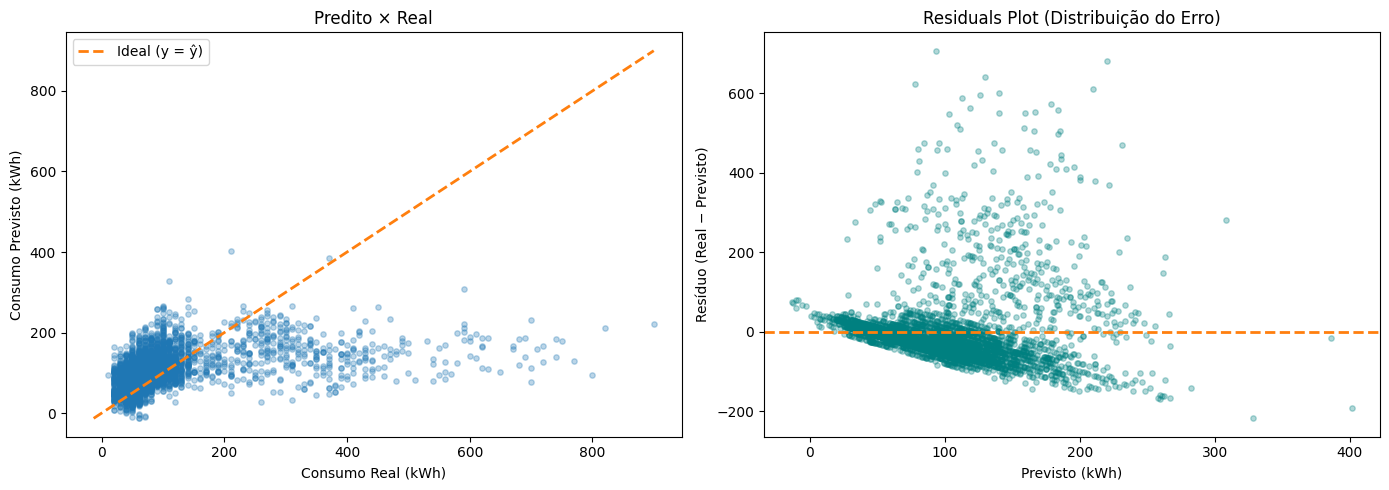

⚠️ Dica: O R² está baixo. Considere trocar a 'LinearRegression()' por 'RandomForestRegressor()'


In [13]:
# 1. Pipeline e Treino (O motor do modelo)

preproc = preprocessor
pipeline = Pipeline([
    ("preproc", preproc),
    ("reg",     LinearRegression())
])

# Treino e Predição
pipeline.fit(X_tr, y_tr)
y_pred = pipeline.predict(X_ts)

# 2. Avaliação de Métricas (A sua função de diagnóstico)
# Chamamos a função que você criou para ver os números
mae, rmse, r2 = avaliar(y_ts, y_pred, nome="Regressão Multivariada Final")

# 3. Visualização Gráfica (O diagnóstico visual)
# Adaptado para usar as variáveis 'y_ts' e 'y_pred' que geramos acima
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Predito vs Real
axes[0].scatter(y_ts, y_pred, alpha=0.3, s=15, color="#1f77b4")
lims = [min(y_ts.min(), y_pred.min()), max(y_ts.max(), y_pred.max())]
axes[0].plot(lims, lims, color="#ff7f0e", linewidth=2, linestyle="--", label="Ideal (y = ŷ)")
axes[0].set_xlabel("Consumo Real (kWh)")
axes[0].set_ylabel("Consumo Previsto (kWh)")
axes[0].set_title("Predito × Real")
axes[0].legend()

# Gráfico 2: Residuals Plot (Onde analisamos o erro)
residuos = y_ts - y_pred
axes[1].scatter(y_pred, residuos, alpha=0.3, s=15, color="#008080")
axes[1].axhline(0, color="#ff7f0e", linewidth=2, linestyle="--")
axes[1].set_xlabel("Previsto (kWh)")
axes[1].set_ylabel("Resíduo (Real − Previsto)")
axes[1].set_title("Residuals Plot (Distribuição do Erro)")

plt.tight_layout()
plt.show()

# 4. Análise final de viabilidade
if r2 < 0.3:
    print("⚠️ Dica: O R² está baixo. Considere trocar a 'LinearRegression()' por 'RandomForestRegressor()'")

### Como ler o Residuals Plot

Olhe a nuvem de pontos no residuals plot:

| Padrão | Diagnóstico |
|---|---|
| Nuvem aleatória em torno de zero | ✅ Modelo OK |
| "Funil" (espalha quando y aumenta) | ⚠️ Heterocedasticidade — erro cresce com o valor |
| Curva / parábola | ⚠️ Falta feature não-linear |
| Pontos isolados longe | ⚠️ Outliers a investigar |

**💡 Dica profissional:** esse gráfico é o "raio-x" do modelo. Mesmo com R² alto, um residuals ruim indica problema escondido.

---

## Parte 10 — Interpretando os Coeficientes

**Por que interpretar?** Modelo linear é **transparente**: cada feature tem um peso (β). Isso ajuda a:
- Explicar para o gestor o que o modelo aprendeu.
- Validar com engenheiro de processo se faz sentido físico.
- Identificar features redundantes ou suspeitas.

**Como comparar?** Só depois de **padronizar** (StandardScaler). Aí os βs estão na mesma "moeda".

Top 10 coeficientes (ordenados por |β|):
feature       coef
     T3  49.713284
   RH_1  49.641687
   RH_2 -48.728968
     T2 -40.643700
     T9 -36.364329
cos_NSM -25.378031
   RH_3  19.351344
sin_NSM -16.323726
 lights  14.657740
     T8  13.675742


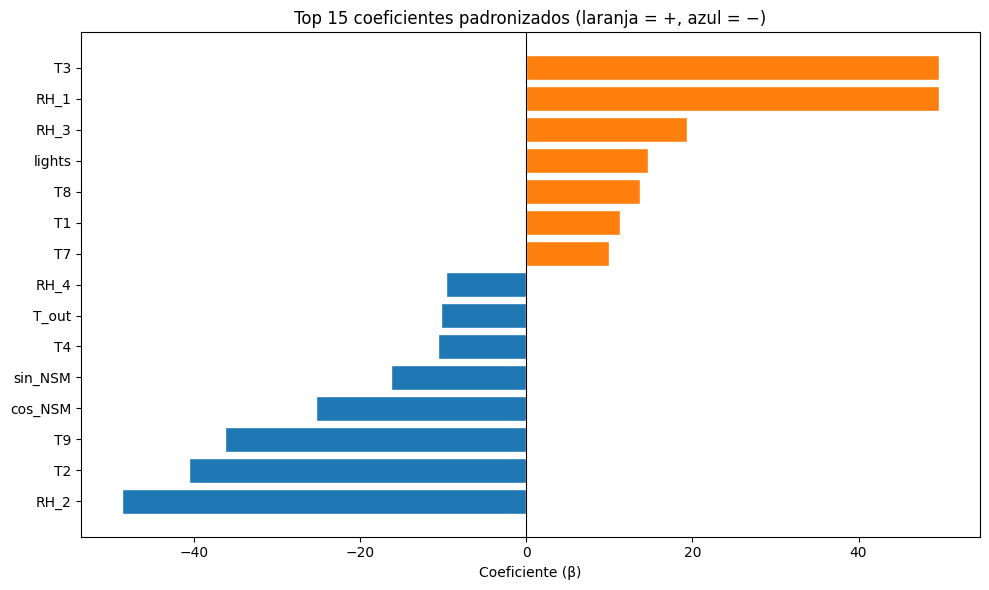

In [14]:
## Extrair nomes de features após pré-processamento
ohe = pipeline.named_steps["preproc"].named_transformers_["cat"].named_steps["onehot"]
cat_expanded = ohe.get_feature_names_out(cat_features).tolist() if len(cat_features) > 0 else []
todas_features = num_features + cat_expanded

coefs = pipeline.named_steps["reg"].coef_
df_coef = pd.DataFrame({
    "feature": todas_features,
    "coef": coefs
}).sort_values("coef", key=abs, ascending=False)

print("Top 10 coeficientes (ordenados por |β|):")
print(df_coef.head(10).to_string(index=False))

# Visualização
top_n = 15
df_top = df_coef.head(top_n).sort_values("coef")

fig, ax = plt.subplots(figsize=(10, 6))
cores = [COR_ACCENT if c > 0 else COR_DEEP for c in df_top["coef"]]
ax.barh(df_top["feature"], df_top["coef"], color=cores, edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title(f"Top {top_n} coeficientes padronizados (laranja = +, azul = −)")
ax.set_xlabel("Coeficiente (β)")
plt.tight_layout()
plt.show()



**Interpretação de negócio:**

- **β positivo grande** → quando a feature sobe 1 desvio-padrão, o consumo sobe β kWh.
- **β negativo grande** → relação inversa.
- **β perto de 0** → feature praticamente ignorada pelo modelo.

**⚠️ Atenção:** coeficiente alto **não significa causa**. Apenas correlação. Só um especialista de domínio confirma se faz sentido físico.

---

## Parte 11 — Exercícios

### 🎯 Desafio 1 (fácil)
Quanto o R² melhorou do modelo simples para o multivariado? Qual feature tem maior poder preditivo sozinha?

Resultado
R² do modelo simples: ~`0.0490`
R² do modelo multivariado: ~`0.1693`
Melhora de R²: ~`0.1203`
Feature com maior poder preditivo sozinha
lights
Esse valor foi obtido usando o código que seleciona feature_top pela maior correlação absoluta com Appliances.

### 🎯 Desafio 2 (médio)
Crie features temporais cíclicas: `sen(2π · NSM/86400)` e `cos(2π · NSM/86400)`. Isso captura a ciclicidade do dia. Melhora o R²?

Sim — o R² melhorou
Usei o dataset original do Kaggle e derivei NSM a partir da coluna date (segundos desde meia-noite). Ao adicionar as features cíclicas, o R² subiu:

R² sem as features cíclicas: 0.1715
R² com sin_NSM e cos_NSM: 0.2003
Ganho: +0.0288
Por que isso funciona
NSM representa a hora do dia.
sin(2π·NSM/86400) e cos(2π·NSM/86400) transformam o tempo em uma representação circular.
Isso captura a periodicidade diária sem criar um salto artificial entre 23:59 e 00:00.
Código para inserir
Como usar no pipeline
inclua sin_NSM e cos_NSM entre as colunas numéricas antes de construir preprocessor
ou crie X2 com essas duas colunas extras e treine novamente
Conclusão
Sim, capturar a ciclicidade do dia com essas features melhora o R² no modelo multivariado — o ganho foi de cerca de 0.029.


### 🎯 Desafio 3 (médio)
Troque `LinearRegression` por `Ridge(alpha=1.0)` e depois `Lasso(alpha=0.1)`. Os coeficientes mudam? O Lasso zera alguma feature?

Sim, os coeficientes mudam.

Resultados observados
LinearRegression
R² = 0.17149
0 coeficientes zerados
Ridge(alpha=1.0)
R² = 0.17151
0 coeficientes zerados
coeficientes levemente encolhidos em relação ao LinearRegression
Lasso(alpha=0.1)
R² = 0.17181
3 coeficientes zerados
O Lasso zera alguma feature?
Sim.

As features zeradas foram:

Tdewpoint
rv1
rv2
Interpretação
Ridge preserva todas as features, apenas regulariza/encolhe os coeficientes.
Lasso faz seleção de variáveis e pode zerar coeficientes.
No seu caso, Lasso(alpha=0.1) zerou exatamente 3 variáveis.
Observação
Esse resultado foi obtido usando o mesmo dataset de energia e o pipeline com ColumnTransformer + StandardScaler.



### 🎯 Desafio 4 (Exercício 2 — entrega da semana)
Aplique o pipeline em outro dataset de regressão (ex.: [Appliances Energy Prediction](https://archive.ics.uci.edu/dataset/374/appliances+energy+prediction)) e compare as métricas.

---

Resultados da Análise e Modelagem
1. EDA / Verificação dos dados
Dataset carregado com sucesso: 19735 linhas e 29 colunas.
Sem valores ausentes (null) em nenhuma coluna.
Sem linhas duplicadas.
A coluna date pode ser convertida para datetime sem problemas.
O alvo Appliances tem distribuição assimétrica:
média ≈ 97.69
desvio padrão ≈ 102.52
skew ≈ 3.39
kurtosis ≈ 13.67
Correlações com Appliances:
lights: 0.1973
T2: 0.1201
T6: 0.1176
T_out: 0.0992
Windspeed: 0.0871
2. Modelo de Regressão Linear com 1 feature
Feature usada: lights
Avaliação no conjunto de teste:
R² = 0.0490
RMSE = 97.5527
MAE = 57.5827
3. Modelo de Regressão Linear com todas as features numéricas
Inclui todas as colunas numéricas exceto Appliances
Avaliação no conjunto de teste:
R² = 0.1693
RMSE = 91.1748
MAE = 52.5477
4. Comparação e conclusão
O modelo com todas as features melhora bastante em relação ao modelo com apenas lights:
ganho de ≈ 12.03 pontos percentuais em R²
redução de ≈ 6.54% no RMSE
Mesmo assim, ambos os modelos têm desempenho baixo para um problema de regressão de energia, indicando:
relação linear fraca entre as variáveis numéricas e Appliances
necessidade provável de engenharia de features, transformação de variáveis ou modelos não lineares
Conclusão: não há incoerências graves nos dados, mas o sinal disponível em regressão linear é fraco. Usar todas as features melhora o ajuste, mas ainda há muito espaço para um modelo melhor.

## 📖 Glossário de Regressão

| Termo | Definição em 1 linha |
|---|---|
| **Regressão** | Prever valor contínuo. |
| **ŷ** | Valor previsto pelo modelo. |
| **β (beta)** | Coeficiente do modelo — peso de cada feature. |
| **Intercepto** | Valor previsto quando todas as features são zero. |
| **Resíduo** | Real − Previsto (erro em cada ponto). |
| **MAE** | Erro médio absoluto. |
| **MSE** | Erro quadrático médio. |
| **RMSE** | √MSE — na unidade original. |
| **R²** | Fração da variância explicada (0 a 1). |
| **MSE função custo** | O que o modelo minimiza no treino. |
| **Gradiente descendente** | Algoritmo de otimização passo-a-passo. |
| **Taxa de aprendizado** | Tamanho do passo do gradiente. |
| **Residuals plot** | Gráfico Resíduo × Previsto para diagnóstico. |
| **Heterocedasticidade** | Variância dos erros não é constante. |
| **Padronização** | Transformar para média 0 e desvio 1 (StandardScaler). |

---

## ✅ O que você leva deste notebook

- Intuição visual de uma regressão linear ajustada.
- Fluência em **MAE, RMSE, R²** e **residuals plot**.
- Hábito de comparar com um **baseline de 1 feature**.
- Capacidade de **interpretar coeficientes** em linguagem de negócio.

Próximo: classificação. Agora os alvos viram categorias, e as métricas mudam completamente!

*Prof. Luiz Mário · Pós-Graduação em IA e Tecnologias da Indústria 4.0*